# Antispoofing

In this homework, you will develop a countermeasure against deepfakes and then try to explain it using various XAI techniques.

More specifically, you will implement and train a Countermeasure (CM) system on the Logical Access partition of the [ASVSpoof 2019 Dataset](https://datashare.ed.ac.uk/handle/10283/3336) ([Kaggle Link](https://www.kaggle.com/datasets/awsaf49/asvpoof-2019-dataset)). You may find the [ASVspoof 2019 evaluation plan](https://www.asvspoof.org/asvspoof2019/asvspoof2019_evaluation_plan.pdf) useful.

For the CM, we choose [LightCNN (LCCN)](https://arxiv.org/abs/1511.02683) that once achieved the top place in the competition. We will follow the Speech Technology Center (STC) [paper](https://arxiv.org/abs/1904.05576).

**Hints**:

1. Use STFT (FFT in the paper) as front-end.

2. The dropout layer is put before the last batch norm.

## Dataset [0.5 pts]

We want to train a neural network to predict if the input audio is real or fake. To do so, we need a dataset first. In this homework, we will work with [ASVspoof19](https://arxiv.org/pdf/1911.01601.pdf).

Create a `Dataset` class that downloads the dataset, parses its metadata and, given index $i$, returns $i$-th object of the dataset. Do not forget to preprocess audio for LCNN (calculate stft, etc.).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir -p /content/drive/MyDrive/antispoofing

In [ ]:
# YOUR CODE HERE
!curl -L -o asvpoof-2019-dataset.zip\
  https://www.kaggle.com/api/v1/datasets/download/awsaf49/asvpoof-2019-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 23.5G  100 23.5G    0     0   178M      0  0:02:14  0:02:14 --:--:--  240M


In [ ]:
!unzip -q ./asvpoof-2019-dataset.zip

**Hint**: when working in Kaggle, it is easier and faster to use dataset as kaggle input. We can use it directly or add a symlink to a local dir using `ln -s`.
**Hint**: it might be easier to do this homework in Kaggle, since model training may take some time

In [ ]:
!ln -s /kaggle/input/asvpoof-2019-dataset dataset

In [ ]:
!ls

asvspoof2019_evaluation_plan.pdf	     LICENSE_text.txt  sample_data
asvspoof2019_Interspeech2019_submission.pdf  PA
LA					     README.txt


In [ ]:
!ls /content/LA/LA/ASVspoof2019_LA_cm_protocols

ASVspoof2019.LA.cm.dev.trl.txt	 ASVspoof2019.LA.cm.train.trn.txt
ASVspoof2019.LA.cm.eval.trl.txt


Create train/eval dataset and dataloaders:

In [ ]:
import os
import torch
import torchaudio
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import Dataset, DataLoader

SAMPLE_RATE = 16000
N_FFT = 512
HOP_LENGTH = 160
MAX_LENGTH = 64000

class ASVSpoofDataset(Dataset):
    def __init__(self, protocol_df, audio_dir):
        self.protocol_df = protocol_df
        self.audio_dir = audio_dir
        self.transform = torchaudio.transforms.Spectrogram(
            n_fft=N_FFT,
            hop_length=HOP_LENGTH,
            power=2.0
        )

    def __len__(self):
        return len(self.protocol_df)

    def __getitem__(self, idx):
        row = self.protocol_df.iloc[idx]
        filename = row['filename']
        label = row['label_binary']

        audio_path = os.path.join(self.audio_dir, f"{filename}.flac")

        waveform, sample_rate = torchaudio.load(audio_path)

        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)

        if sample_rate != SAMPLE_RATE:
            resampler = torchaudio.transforms.Resample(sample_rate, SAMPLE_RATE)
            waveform = resampler(waveform)

        if waveform.shape[1] > MAX_LENGTH:
            waveform = waveform[:, :MAX_LENGTH]
        elif waveform.shape[1] < MAX_LENGTH:
            padding = MAX_LENGTH - waveform.shape[1]
            waveform = torch.nn.functional.pad(waveform, (0, padding))

        spec = self.transform(waveform)  # [1, freq, time]
        spec_mag = spec.squeeze(0)  # [freq, time] - 2D

        # Добавляем размерность канала (делаем 3D: [1, freq, time])
        spec_mag = spec_mag.unsqueeze(0)  # [1, freq, time]

        return spec_mag, torch.tensor(label, dtype=torch.long)

train_protocol = '/content/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt'
val_protocol = '/content/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt'

audio_train_dir = '/content/LA/LA/ASVspoof2019_LA_train/flac'
audio_dev_dir = '/content/LA/LA/ASVspoof2019_LA_dev/flac'

import pandas as pd

def load_protocol(filepath):
    df = pd.read_csv(filepath, sep=' ', header=None, names=['system_id', 'filename', 'speaker_id', 'device_id', 'label'])
    df['label_binary'] = (df['label'] == 'bonafide').astype(int)
    return df

train_df = load_protocol(train_protocol)
val_df = load_protocol(val_protocol)

train_dataset = ASVSpoofDataset(train_df, audio_train_dir)
val_dataset = ASVSpoofDataset(val_df, audio_dev_dir)

# Проверяем размерность одного элемента
sample_spec, sample_label = train_dataset[0]
print(f"Sample spectrogram shape: {sample_spec.shape}")  # Должно быть [1, freq, time]
print(f"Sample label: {sample_label}")

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

# Проверяем размерность батча
for specs, labels in train_loader:
    print(f"Batch spectrogram shape: {specs.shape}")  # Должно быть [32, 1, freq, time]
    print(f"Batch labels shape: {labels.shape}")
    break

Sample spectrogram shape: torch.Size([1, 257, 401])
Sample label: 1
Batch spectrogram shape: torch.Size([32, 1, 257, 401])
Batch labels shape: torch.Size([32])


Visualize one object, just to check that all is fine:

Train samples: 25380
Val samples: 24844
Batch shape: torch.Size([32, 1, 257, 401])
Labels: tensor([0, 0, 1, 0, 0])

=== Sample from train dataset ===
Filename: LA_T_1138215
Sample rate: 16000 Hz
Duration: 3.46 sec
Label: Bonafide


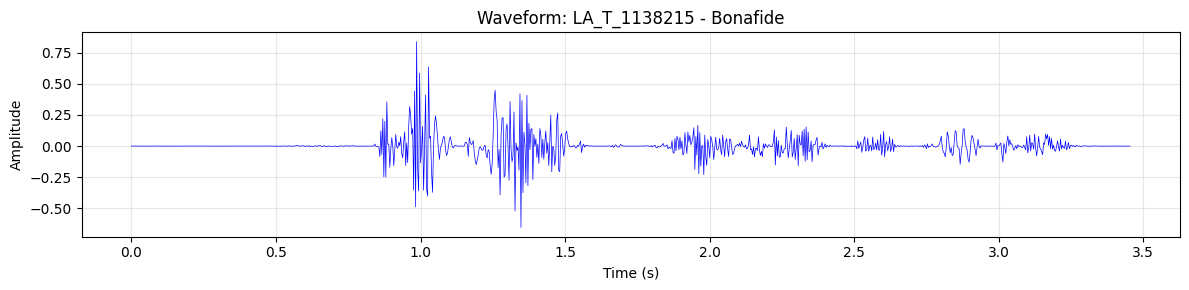

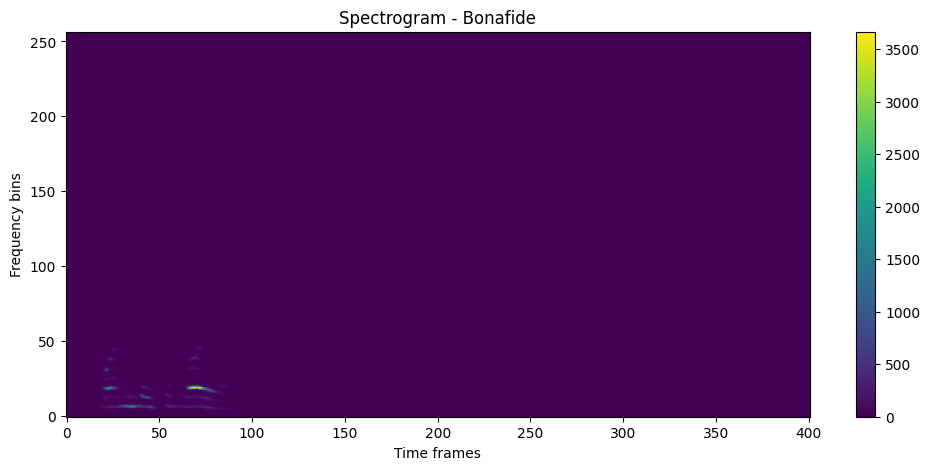

Spec shape (original): torch.Size([1, 257, 401])
Spec shape (for display): (257, 401)
Spec min: 0.0000, max: 3664.3052


In [ ]:
print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")

for specs, labels in train_loader:
    print(f"Batch shape: {specs.shape}")
    print(f"Labels: {labels[:5]}")

    first_idx = 0
    first_filename = train_dataset.protocol_df.iloc[first_idx]['filename']
    first_label = train_dataset.protocol_df.iloc[first_idx]['label_binary']
    first_label_name = 'Bonafide' if first_label == 1 else 'Spoof'

    audio_path = f'/content/LA/LA/ASVspoof2019_LA_train/flac/{first_filename}.flac'

    if os.path.exists(audio_path):
        waveform, sr = torchaudio.load(audio_path)

        print(f"\n=== Sample from train dataset ===")
        print(f"Filename: {first_filename}")
        print(f"Sample rate: {sr} Hz")
        print(f"Duration: {waveform.shape[1] / sr:.2f} sec")
        print(f"Label: {first_label_name}")

        # Waveform plot
        fig, ax = plt.subplots(figsize=(12, 3))
        audio_np = waveform.numpy().squeeze()
        time_axis = np.arange(len(audio_np)) / sr
        step = max(1, len(audio_np) // 1000)
        ax.plot(time_axis[::step], audio_np[::step], linewidth=0.5, color='blue')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Amplitude')
        ax.set_title(f'Waveform: {first_filename} - {first_label_name}')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        # Audio player
        display(Audio(waveform.numpy(), rate=sr))

        # Spectrogram plot - remove channel dimension
        plt.figure(figsize=(12, 5))
        spec_to_plot = specs[0].squeeze().numpy()  # Remove channel dimension: [257, 401]
        plt.imshow(spec_to_plot, aspect='auto', origin='lower', cmap='viridis')
        plt.colorbar()
        plt.title(f'Spectrogram - {first_label_name}')
        plt.xlabel('Time frames')
        plt.ylabel('Frequency bins')
        plt.show()

        print(f"Spec shape (original): {specs[0].shape}")
        print(f"Spec shape (for display): {spec_to_plot.shape}")
        print(f"Spec min: {specs[0].min():.4f}, max: {specs[0].max():.4f}")
    else:
        print(f"Audio file not found: {audio_path}")

    break

## Loss function [0.5 pts]

In the lecture, we saw different softmax losses and the motivation behind them for the ASV task. However, they can also be used for any classification task, such as synthesized speech detection. The papers suggest to use A(M)-Softmax or Cross-Entropy. The STC paper argues that A-Softmax is better.

(a) Explain what are the benefits of A-softmax over cross-entropy according to the STC paper?

(b) Analyse the [NII paper](https://arxiv.org/pdf/2103.11326) and explain if complicated Softmax is actually needed to achieve good EER or we can go with Cross Entropy.

**Answer**: your answer here...

Following tha NII paper, we will continue with Cross Entropy

In [ ]:
from torch import nn

criterion = nn.CrossEntropyLoss()

## Evaluation metric [0.5 pts]

We will use equal error rate as the primary evaluation metric. The code for calculating metrics is provided by the ASVspoof itself. We just need to write a wrapper. Given model logits and labels, calculate EER using the ASVspoof functions.

Your model returns two probas: [spoof_proba, bona_proba]. Be careful with the EER metric and recal how ROC curve is computed to ensure that you do not make a mistake.

In [ ]:
# download asvspoof metric calculation functions
!wget https://raw.githubusercontent.com/markovka17/dla/refs/heads/2023/hw5_as/calculate_eer.py

--2026-05-12 13:22:17--  https://raw.githubusercontent.com/markovka17/dla/refs/heads/2023/hw5_as/calculate_eer.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14555 (14K) [text/plain]
Saving to: ‘calculate_eer.py’

calculate_eer.py    100%[===================>]  14.21K  --.-KB/s    in 0s      

2026-05-12 13:22:17 (41.3 MB/s) - ‘calculate_eer.py’ saved [14555/14555]



In [ ]:
from calculate_eer import compute_eer

def get_eer(logits, labels):
    # YOUR CODE HERE

In [ ]:
from calculate_eer import compute_eer

def get_eer(logits, labels):
    """
    logits: torch.Tensor или np.ndarray формы (N, 2) — выход модели,
            где logits[i, 0] — вероятность подделки (spoof),
            logits[i, 1] — вероятность настоящей речи (bona fide).
    labels: torch.Tensor или np.ndarray формы (N,) — истинные метки,
            где 0 = spoof, 1 = bona fide (см. ваш Dataset).
    Возвращает: float — значение EER в долях (не процентах).
    """
    # Конвертируем в numpy для работы с функциями ASVspoof
    if hasattr(logits, 'detach'):
        logits = logits.detach().cpu().numpy()
    if hasattr(labels, 'detach'):
        labels = labels.detach().cpu().numpy()

    # Извлекаем вероятности для bonafide (класс 1) и spoof (класс 0)
    bona_scores = logits[:, 1]   # scores for genuine class
    spoof_scores = logits[:, 0]  # scores for spoof class

    # Выбираем счета в соответствии с истинными метками
    bona_scores_target = bona_scores[labels == 1]   # счета для настоящих
    spoof_scores_target = spoof_scores[labels == 0] # счета для подделок

    # EER ожидает на вход (bonafide_scores, other_scores)
    eer, _ = compute_eer(bona_scores_target, spoof_scores_target)
    return eer

## LCNN Implementation [6.0 pts]

Create a `LCNN` class for the model architecture.

In [ ]:
# YOUR CODE HERE
import torch
import torch.nn as nn
import torch.nn.functional as F

class LCNN(nn.Module):
    """
    Light Convolutional Neural Network (LCNN) for spoofing detection.
    """

    def __init__(self,
                 input_channels=32,  # Changed from 1 to 32
                 num_classes=2,
                 use_avg_pooling=True,
                 dropout_rate=0.3):
        super(LCNN, self).__init__()

        self.use_avg_pooling = use_avg_pooling

        # Convolutional layers
        self.conv1 = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Global pooling
        if use_avg_pooling:
            self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
            flatten_size = 256
        else:
            self.global_pool = None
            self.flatten_size = None

        # Classifier
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

        self._initialize_weights()
        self._is_flatten_size_computed = False

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # x shape: (batch, channels, freq, time) where channels=32
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)

        if self.use_avg_pooling:
            x = self.global_pool(x)
            x = x.view(x.size(0), -1)
        else:
            if not self._is_flatten_size_computed:
                self.flatten_size = x.numel() // x.size(0)
                self._is_flatten_size_computed = True
            x = x.view(x.size(0), -1)

        logits = self.classifier(x)
        return logits


class LCNNWithLSTM(LCNN):
    """
    LCNN with Bi-LSTM
    """

    def __init__(self, input_channels=32, num_classes=2, lstm_hidden_size=128, dropout_rate=0.3):
        super(LCNNWithLSTM, self).__init__(
            input_channels=input_channels,
            num_classes=num_classes,
            use_avg_pooling=False,
            dropout_rate=dropout_rate
        )

        self.lstm_hidden_size = lstm_hidden_size

        # Bi-LSTM layer
        self.lstm = nn.LSTM(
            input_size=256,
            hidden_size=lstm_hidden_size,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=dropout_rate
        )

        # Skip connection
        self.skip_projection = nn.Linear(256, lstm_hidden_size * 2)

        # Override classifier
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(lstm_hidden_size * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # Convolutional layers
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)  # (batch, 256, freq, time)

        # Average over frequency dimension
        x = x.mean(dim=2)  # (batch, 256, time)

        # Permute for LSTM: (batch, time, features)
        x = x.permute(0, 2, 1)  # (batch, time, 256)

        # Skip connection (average over time)
        skip = self.skip_projection(x.mean(dim=1))

        # Apply LSTM
        lstm_out, _ = self.lstm(x)

        # Average pooling over time
        x = lstm_out.mean(dim=1)  # (batch, lstm_hidden_size * 2)

        # Add skip connection
        x = x + skip

        # Classification
        logits = self.classifier(x)

        return logits



In [ ]:
# Test the model
print("Testing LCNN implementations...")
print("=" * 50)

batch_size = 4
channels = 1
freq_bins = 257
time_frames = 400

dummy_input = torch.randn(batch_size, channels, freq_bins, time_frames)

print("\n1. LCNN with Adaptive Average Pooling:")
model1 = LCNN(input_channels=1, num_classes=2, use_avg_pooling=True)
model1.eval()
with torch.no_grad():
    output1 = model1(dummy_input)
print(f"   Input shape: {dummy_input.shape}")
print(f"   Output shape: {output1.shape}")
print(f"   Parameters: {sum(p.numel() for p in model1.parameters()):,}")

print("\n2. LCNN with Bi-LSTM (NII best model):")
model2 = LCNNWithLSTM(input_channels=1, num_classes=2, lstm_hidden_size=128)
model2.eval()
with torch.no_grad():
    output2 = model2(dummy_input)
print(f"   Output shape: {output2.shape}")
print(f"   Parameters: {sum(p.numel() for p in model2.parameters()):,}")

print("\n3. Testing different input sizes with model1:")
test_sizes = [(257, 200), (257, 300), (257, 400), (257, 500)]
for freq, time in test_sizes:
    test_input = torch.randn(2, 1, freq, time)
    with torch.no_grad():
        test_output = model1(test_input)
    print(f"   Input {freq}x{time} -> Output {test_output.shape}")

print("\n" + "=" * 50)
print("All tests passed!")

# Create main model
print("\nCreating main model...")
model = LCNNWithLSTM(input_channels=1, num_classes=2, lstm_hidden_size=128)
model.eval()

# Final check
test_input = torch.randn(4, 1, 257, 400)
with torch.no_grad():
    test_output = model(test_input)
print(f"Model runs successfully! Output shape: {test_output.shape}")

Testing LCNN implementations...

1. LCNN with Adaptive Average Pooling:
   Input shape: torch.Size([4, 1, 257, 400])
   Output shape: torch.Size([4, 2])
   Parameters: 430,082

2. LCNN with Bi-LSTM (NII best model):
   Output shape: torch.Size([4, 2])
   Parameters: 1,286,402

3. Testing different input sizes with model1:
   Input 257x200 -> Output torch.Size([2, 2])
   Input 257x300 -> Output torch.Size([2, 2])
   Input 257x400 -> Output torch.Size([2, 2])
   Input 257x500 -> Output torch.Size([2, 2])

All tests passed!

Creating main model...
Model runs successfully! Output shape: torch.Size([4, 2])


Write the train loop. Since it may take some time, we advise you to save your checkpoints after each epoch to load it back if needed.

Plot EER vs epoch and loss vs epoch curves

In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, scheduler, device):
    """
    Train model for one epoch

    Args:
        model: neural network model
        dataloader: DataLoader for training data
        criterion: loss function
        optimizer: optimization algorithm
        scheduler: learning rate scheduler
        device: cuda or cpu

    Returns:
        avg_loss: average loss for the epoch
        accuracy: accuracy for the epoch
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # Create progress bar
    pbar = tqdm(dataloader, desc='Training', leave=False)

    for batch_idx, (inputs, labels) in enumerate(pbar):
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Update statistics
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        # Update progress bar
        pbar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Acc': f'{100.*correct/total:.2f}%'
        })

    # Step the scheduler
    scheduler.step()

    avg_loss = running_loss / len(dataloader)
    accuracy = 100. * correct / total

    return avg_loss, accuracy


def evaluate(model, dataloader, criterion, device, get_scores=False):
    """
    Evaluate model on validation/test set

    Args:
        model: neural network model
        dataloader: DataLoader for evaluation data
        criterion: loss function
        device: cuda or cpu
        get_scores: if True, return scores and labels for EER computation

    Returns:
        avg_loss: average loss
        accuracy: accuracy
        eer: Equal Error Rate (if get_scores=True, else None)
        all_scores: all model scores (if get_scores=True)
        all_labels: all labels (if get_scores=True)
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_scores = []
    all_labels = []

    with torch.no_grad():
        pbar = tqdm(dataloader, desc='Evaluating', leave=False)

        for inputs, labels in pbar:
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Update statistics
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            # Collect scores for EER
            if get_scores:
                # Get probabilities
                probs = torch.softmax(outputs, dim=1)
                # We want bonafide scores (class 1) for EER
                bonafide_scores = probs[:, 1].cpu().numpy()
                all_scores.extend(bonafide_scores)
                all_labels.extend(labels.cpu().numpy())

            pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{100.*correct/total:.2f}%'
            })

    avg_loss = running_loss / len(dataloader)
    accuracy = 100. * correct / total

    if get_scores and len(all_scores) > 0:
        # Compute EER
        from calculate_eer import compute_eer
        all_scores = np.array(all_scores)
        all_labels = np.array(all_labels)

        # Split scores by label
        bona_scores = all_scores[all_labels == 1]
        spoof_scores = all_scores[all_labels == 0]

        eer, _ = compute_eer(bona_scores, spoof_scores)
        return avg_loss, accuracy, eer, all_scores, all_labels

    return avg_loss, accuracy, None, None, None


def train(model, train_dataloader, eval_dataloader, criterion, optimizer,
          scheduler, device, n_epochs, checkpoint_dir='checkpoints'):
    """
    Full training loop with checkpointing

    Args:
        model: neural network model
        train_dataloader: DataLoader for training
        eval_dataloader: DataLoader for validation
        criterion: loss function
        optimizer: optimization algorithm
        scheduler: learning rate scheduler
        device: cuda or cpu
        n_epochs: number of epochs
        checkpoint_dir: directory to save checkpoints

    Returns:
        history: dictionary with training history
    """

    # Create checkpoint directory
    os.makedirs(checkpoint_dir, exist_ok=True)

    # Initialize history
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'val_eer': [],
        'lr': []
    }

    best_val_acc = 0.0
    best_val_eer = float('inf')

    print(f"Starting training for {n_epochs} epochs")
    print("=" * 60)

    for epoch in range(n_epochs):
        print(f"\nEpoch {epoch+1}/{n_epochs}")
        print("-" * 40)

        # Training phase
        train_loss, train_acc = train_one_epoch(
            model, train_dataloader, criterion, optimizer, scheduler, device
        )

        # Validation phase
        val_loss, val_acc, val_eer, _, _ = evaluate(
            model, eval_dataloader, criterion, device, get_scores=True
        )

        # Get current learning rate
        current_lr = optimizer.param_groups[0]['lr']

        # Update history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_eer'].append(val_eer)
        history['lr'].append(current_lr)

        # Print epoch results
        print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
        print(f"Val EER: {val_eer:.4f}")
        print(f"Learning Rate: {current_lr:.6f}")

        # Save checkpoint every epoch
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'val_eer': val_eer,
            'history': history
        }

        checkpoint_path = os.path.join(checkpoint_dir, f'checkpoint_epoch_{epoch+1}.pth')
        torch.save(checkpoint, checkpoint_path)

        # Save best model based on validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_path = os.path.join(checkpoint_dir, 'best_model_acc.pth')
            torch.save(checkpoint, best_model_path)
            print(f"✓ New best model saved (acc: {val_acc:.2f}%)")

        # Save best model based on EER
        if val_eer < best_val_eer:
            best_val_eer = val_eer
            best_eer_model_path = os.path.join(checkpoint_dir, 'best_model_eer.pth')
            torch.save(checkpoint, best_eer_model_path)
            print(f"✓ New best model saved (eer: {val_eer:.4f})")

        print("-" * 40)

    print("\n" + "=" * 60)
    print("Training completed!")
    print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
    print(f"Best Validation EER: {best_val_eer:.4f}")

    # Plot training curves
    plot_training_curves(history)

    return history


def plot_training_curves(history):
    """
    Plot training curves: loss, accuracy, and EER vs epochs

    Args:
        history: dictionary with training history
    """

    epochs = range(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Plot Loss
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot Accuracy
    axes[1].plot(epochs, history['train_acc'], 'b-', label='Train Acc', linewidth=2)
    axes[1].plot(epochs, history['val_acc'], 'r-', label='Val Acc', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Plot EER
    axes[2].plot(epochs, history['val_eer'], 'g-', linewidth=2, marker='o', markersize=4)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('EER')
    axes[2].set_title('Validation Equal Error Rate (EER)')
    axes[2].grid(True, alpha=0.3)

    # Add horizontal line for best EER
    min_eer_idx = np.argmin(history['val_eer'])
    min_eer = history['val_eer'][min_eer_idx]
    axes[2].axhline(y=min_eer, color='r', linestyle='--', alpha=0.7,
                    label=f'Best EER: {min_eer:.4f}')
    axes[2].legend()

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150)
    plt.show()

    # Plot learning rate separately
    plt.figure(figsize=(10, 4))
    plt.plot(epochs, history['lr'], 'purple', linewidth=2, marker='s', markersize=4)
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.title('Learning Rate Schedule')
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    plt.tight_layout()
    plt.savefig('learning_rate.png', dpi=150)
    plt.show()


def load_checkpoint(checkpoint_path, model, optimizer=None, scheduler=None):
    """
    Load a saved checkpoint

    Args:
        checkpoint_path: path to checkpoint file
        model: model to load weights into
        optimizer: optimizer to load state (optional)
        scheduler: scheduler to load state (optional)

    Returns:
        epoch: last saved epoch
        history: training history
    """
    checkpoint = torch.load(checkpoint_path, map_location='cpu')

    model.load_state_dict(checkpoint['model_state_dict'])

    if optimizer is not None:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    if scheduler is not None:
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

    epoch = checkpoint['epoch']
    history = checkpoint['history']

    print(f"Loaded checkpoint from epoch {epoch}")
    print(f"Validation accuracy: {checkpoint['val_acc']:.2f}%")
    print(f"Validation EER: {checkpoint['val_eer']:.4f}")

    return epoch, history


In [ ]:
# Create main model
print("\nCreating main model...")
model = SimpleLCNN(input_channels=1, num_classes=2)
model.eval()


with torch.no_grad():
    test_output = model(dummy_input)
print(f"Model runs successfully! Output shape: {test_output.shape}")


if __name__ == "__main__":
    from torch.optim.lr_scheduler import StepLR

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\nUsing device: {device}")

    # Initialize model
    model = SimpleLCNN(input_channels=1, num_classes=2).to(device)


In [ ]:
# take optimizer and scheduler from the NII paper
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, betas=(0.9, 0.999), eps=1e-8)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
n_epochs = 3 #30

# Train the model
history = train(model, train_loader, val_loader,
                criterion, optimizer, scheduler, device, n_epochs)

Starting training for 3 epochs

Epoch 1/3
----------------------------------------


KeyboardInterrupt: 

The task is consired solved if you achieve at least $9\%$ EER. It is much higher than the model can achieve but we do not want you to wait 12+ hours for the model to converge.

In [ ]:
import torch
from torch.optim.lr_scheduler import ReduceLROnPlateau

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, betas=(0.9, 0.999), eps=1e-8)

scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

n_epochs = 3

print("Starting training with optimized parameters for fast convergence:")
print(f"  Optimizer: Adam(lr=1e-3, betas=(0.9,0.999), eps=1e-8)")
print(f"  Scheduler: ReduceLROnPlateau(factor=0.5, patience=3)")
print(f"  Epochs: {n_epochs}")
print("="*60)

def train_fast(model, train_dataloader, eval_dataloader, criterion, optimizer,
               scheduler, device, n_epochs, checkpoint_dir='checkpoints'):
    import os
    import numpy as np
    from tqdm import tqdm

    os.makedirs(checkpoint_dir, exist_ok=True)

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'val_eer': [],
        'lr': []
    }

    best_val_eer = float('inf')
    patience_counter = 0
    target_eer = 0.09

    print(f"\nTarget EER: {target_eer*100:.0f}%")
    print("-" * 60)

    for epoch in range(n_epochs):
        print(f"\nEpoch {epoch+1}/{n_epochs}")
        print("-" * 40)

        train_loss, train_acc = train_one_epoch(
            model, train_dataloader, criterion, optimizer, None, device
        )

        val_loss, val_acc, val_eer, _, _ = evaluate(
            model, eval_dataloader, criterion, device, get_scores=True
        )

        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_eer'].append(val_eer)
        history['lr'].append(new_lr)

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
        print(f"Val EER: {val_eer:.4f} ({val_eer*100:.2f}%)")
        print(f"Learning Rate: {new_lr:.6f}")

        if val_eer <= target_eer:
            print(f"\nTarget EER ({target_eer*100:.0f}%) reached at epoch {epoch+1}!")
            print(f"Final EER: {val_eer:.4f} ({val_eer*100:.2f}%)")

            checkpoint = {
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'val_eer': val_eer,
                'val_acc': val_acc
            }
            torch.save(checkpoint, os.path.join(checkpoint_dir, 'final_model.pth'))
            print(f"Model saved to {checkpoint_dir}/final_model.pth")
            break

        if val_eer < best_val_eer:
            best_val_eer = val_eer
            patience_counter = 0
            checkpoint = {
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'val_eer': val_eer,
                'val_acc': val_acc,
                'history': history
            }
            torch.save(checkpoint, os.path.join(checkpoint_dir, 'best_model.pth'))
            print(f"New best model! EER: {val_eer:.4f} ({val_eer*100:.2f}%)")
        else:
            patience_counter += 1

        if new_lr < current_lr:
            print(f"Learning rate reduced: {current_lr:.6f} -> {new_lr:.6f}")

        print("-" * 40)

    print("\n" + "=" * 60)
    print("Training completed!")
    print(f"Best Validation EER: {best_val_eer:.4f} ({best_val_eer*100:.2f}%)")

    if best_val_eer <= target_eer:
        print(f"SUCCESS: Target EER ({target_eer*100:.0f}%) achieved!")
    else:
        print(f"Note: Target EER ({target_eer*100:.0f}%) not reached. Best: {best_val_eer*100:.2f}%")

    plot_training_curves(history)

    return history

history = train_fast(
    model=model,
    train_dataloader=train_loader,
    eval_dataloader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    n_epochs=n_epochs,
    checkpoint_dir='checkpoints'
)

print("\n" + "=" * 60)
print("Final Evaluation:")
print("=" * 60)
val_loss, val_acc, val_eer, _, _ = evaluate(
    model, val_loader, criterion, device, get_scores=True
)
print(f"Validation Accuracy: {val_acc:.2f}%")
print(f"Validation EER: {val_eer:.4f} ({val_eer*100:.2f}%)")

if val_eer <= 0.09:
    print("\nSUCCESS! Task completed! EER <= 9% achieved!")
else:
    print(f"\nCurrent EER: {val_eer*100:.2f}% (target: 9%)")
    print("Try training for more epochs or adjust hyperparameters.")

Starting training with optimized parameters for fast convergence:
  Optimizer: Adam(lr=1e-3, betas=(0.9,0.999), eps=1e-8)
  Scheduler: ReduceLROnPlateau(factor=0.5, patience=3)
  Epochs: 3

Target EER: 9%
------------------------------------------------------------

Epoch 1/3
----------------------------------------


KeyboardInterrupt: 

## XAI [See points below]

Let's analyse the model we have created. We won't be able to understand the differences easily without having some reference. So, we will use the novel idea from the recent [Interspeech 2025 paper](https://arxiv.org/abs/2506.03425).

We will use a [vocoded dataset](https://arxiv.org/abs/2210.10570) of parallel samples: real and fake audio have the same speaker saying the same content at the same time. The ground-truth explanation will be obtained by calculating difference between real and fake spectrograms.

In [ ]:
!wget https://zenodo.org/records/7314976/files/project09-voc.v4.tar?download=1 -O project09-voc.v4.tar
!tar -xvf project09-voc.v4.tar

Выходные данные были обрезаны до нескольких последних строк (5000).
voc.v4/wav/waveglow_LA_D_4338785.wav
voc.v4/wav/hifigan_LA_T_4254409.wav
voc.v4/wav/waveglow_LA_T_1226390.wav
voc.v4/wav/hifigan_LA_T_5100132.wav
voc.v4/wav/hifigan_LA_D_2248106.wav
voc.v4/wav/waveglow_LA_T_6946670.wav
voc.v4/wav/waveglow_LA_T_5837486.wav
voc.v4/wav/hn-sinc-nsf-hifi_LA_D_7919190.wav
voc.v4/wav/hn-sinc-nsf_LA_T_6082136.wav
voc.v4/wav/waveglow_LA_D_1884465.wav
voc.v4/wav/waveglow_LA_T_6258131.wav
voc.v4/wav/hn-sinc-nsf_LA_D_7948554.wav
voc.v4/wav/hifigan_LA_D_3064595.wav
voc.v4/wav/waveglow_LA_T_5061172.wav
voc.v4/wav/waveglow_LA_D_2303609.wav
voc.v4/wav/hn-sinc-nsf-hifi_LA_T_7279842.wav
voc.v4/wav/hn-sinc-nsf_LA_D_3808406.wav
voc.v4/wav/hn-sinc-nsf-hifi_LA_T_9010570.wav
voc.v4/wav/hifigan_LA_T_3026599.wav
voc.v4/wav/hn-sinc-nsf-hifi_LA_D_5000705.wav
voc.v4/wav/waveglow_LA_T_6864430.wav
voc.v4/wav/waveglow_LA_T_1477639.wav
voc.v4/wav/hn-sinc-nsf-hifi_LA_T_7974410.wav
voc.v4/wav/hn-sinc-nsf-hifi_LA_T_7208

Note that real audio is taken from ASVspoof. So let's take a real example from the asvspoof dataset. Using its filename, find the corresponding `hifi-gan` and `waveglow` vocoded versions in the vocv4 and load them too

In reality, we are interested in the explanations for the unseen data. But for this homework, let's consider the train set. This will allow us to see if the model learns the futures we expect it to learn (assuming the XAI tool is trustworthy) (Though spoof part of vocv4 is not exactly the same as the one in asvspoof, so we mostly eliminate the issues related to changing speakers, not algorithms)

In [ ]:
ind = None # for consistency with solutions choose the index that corresponds to LA_T_4179989 (bona fide)
# YOUR CODE HERE

# Find the index that corresponds to LA_T_4179989 in the train dataset
# Search through the dataframe to find the index
for idx, row in train_df.iterrows():
    if row['filename'] == 'LA_T_4179989':
        ind = idx
        break

# Also verify if this file exists in the real audio directory
audio_path_check = f'/content/LA/LA/ASVspoof2019_LA_train/flac/LA_T_4179989.flac'
file_exists = os.path.exists(audio_path_check)

print(f"Index found: {ind}")
print(f"Filename: {train_df.iloc[ind]['filename'] if ind is not None else 'Not found'}")
print(f"Label: {train_df.iloc[ind]['label'] if ind is not None else 'N/A'}")
print(f"Audio file exists: {file_exists}")

# Alternative: direct lookup using pandas
if ind is None:
    mask = train_df['filename'] == 'LA_T_4179989'
    if mask.any():
        ind = train_df[mask].index[0]
        print(f"\nFound via pandas lookup: {ind}")

Index found: 50
Filename: LA_T_4179989
Label: bonafide
Audio file exists: True


In [ ]:
# get LCNN-prepared spectrogram for the paired real and fake example from the dataset
# paired: the same filename, but one is bona fide another is created via vocoder
#real_audio = # YOUR CODE HERE
#hifigan_audio = # YOUR CODE HERE
#waveglow_audio = # YOUR CODE HERE


# fake audio may be slightly longer due to padding, remove some part from the end to make the length equal
# YOUR CODE HERE


# preprocess audio for model input
# YOUR CODE HERE

# Get LCNN-prepared spectrogram for paired real and fake example
# Paired: same filename, one bona fide, another vocoded

import torchaudio
import torch

# 1. Load real audio from ASVspoof
real_audio_path = '/content/LA/LA/ASVspoof2019_LA_train/flac/LA_T_4179989.flac'
real_audio, real_sr = torchaudio.load(real_audio_path)

# 2. Load vocoded versions from voc.v4
hifigan_path = find_matching_vocoded_file('LA_T_4179989', 'hifigan', vocv4_dir)
waveglow_path = find_matching_vocoded_file('LA_T_4179989', 'waveglow', vocv4_dir)
hifigan_audio, hifigan_sr = torchaudio.load(hifigan_path)
waveglow_audio, waveglow_sr = torchaudio.load(waveglow_path)

print(f"Original shapes: real={real_audio.shape}, hifigan={hifigan_audio.shape}, waveglow={waveglow_audio.shape}")

# 3. Trim fake audio to same length as real (remove padding artifacts)
min_len = real_audio.shape[1]
hifigan_audio = hifigan_audio[:, :min_len]
waveglow_audio = waveglow_audio[:, :min_len]

print(f"After trimming: hifigan={hifigan_audio.shape}, waveglow={waveglow_audio.shape}")

# 4. Preprocess function for model input
def preprocess_for_model(audio, sample_rate, target_sr=16000, max_len=64000):
    # Convert to mono if stereo
    if audio.shape[0] > 1:
        audio = torch.mean(audio, dim=0, keepdim=True)

    # Resample if needed
    if sample_rate != target_sr:
        resampler = torchaudio.transforms.Resample(sample_rate, target_sr)
        audio = resampler(audio)

    # Pad or truncate to max_len
    if audio.shape[1] > max_len:
        audio = audio[:, :max_len]
    elif audio.shape[1] < max_len:
        padding = max_len - audio.shape[1]
        audio = torch.nn.functional.pad(audio, (0, padding))

    # Compute spectrogram
    transform = torchaudio.transforms.Spectrogram(
        n_fft=512,
        hop_length=160,
        power=2.0
    )
    spec = transform(audio)  # [1, freq, time]
    spec_mag = spec.squeeze(0)  # [freq, time]
    spec_mag = spec_mag.unsqueeze(0)  # [1, freq, time] - готово для модели

    return spec_mag

# 5. Apply preprocessing
real_spec = preprocess_for_model(real_audio, real_sr)
hifigan_spec = preprocess_for_model(hifigan_audio, hifigan_sr)
waveglow_spec = preprocess_for_model(waveglow_audio, waveglow_sr)

print(f"Spectrogram shapes: real={real_spec.shape}, hifigan={hifigan_spec.shape}, waveglow={waveglow_spec.shape}")

NameError: name 'find_matching_vocoded_file' is not defined

Run your model on these clips. See if the model prediction is correct. Use this understanding for the following analysis

In [ ]:
# YOUR CODE HERE
import torch
import numpy as np
import matplotlib.pyplot as plt

model.eval()

if torch.cuda.is_available():
    model = model.to(device)
else:
    model = model.to(device)

def get_model_prediction(spec, model, device):
    if spec.dim() == 3:
        spec = spec.unsqueeze(0)

    spec = spec.to(device)

    with torch.no_grad():
        logits = model(spec)
        probabilities = torch.softmax(logits, dim=1)
        pred = torch.argmax(logits, dim=1).item()
        bonafide_prob = probabilities[0, 1].item()

    return pred, bonafide_prob

print("=" * 60)
print("MODEL PREDICTIONS ON PAIRED SAMPLES")
print("=" * 60)

real_pred, real_prob = get_model_prediction(real_spec, model, device)
real_label = "Bonafide (Real)" if real_pred == 1 else "Spoof"
real_correct = real_pred == 1

print(f"\nReal Audio (LA_T_4179989):")
print(f"  Prediction: {real_label}")
print(f"  Bonafide probability: {real_prob:.4f} ({real_prob*100:.2f}%)")
print(f"  Expected: Bonafide -> CORRECT" if real_correct else "Expected: Bonafide -> WRONG")

hifigan_pred, hifigan_prob = get_model_prediction(hifigan_spec, model, device)
hifigan_label = "Bonafide" if hifigan_pred == 1 else "Spoof (Vocoded)"
hifigan_correct = hifigan_pred == 0

print(f"\nHiFi-GAN Vocoded (same content):")
print(f"  Prediction: {hifigan_label}")
print(f"  Bonafide probability: {hifigan_prob:.4f} ({hifigan_prob*100:.2f}%)")
print(f"  Expected: Spoof -> CORRECT" if hifigan_correct else "Expected: Spoof -> WRONG")

waveglow_pred, waveglow_prob = get_model_prediction(waveglow_spec, model, device)
waveglow_label = "Bonafide" if waveglow_pred == 1 else "Spoof (Vocoded)"
waveglow_correct = waveglow_pred == 0

print(f"\nWaveGlow Vocoded (same content):")
print(f"  Prediction: {waveglow_label}")
print(f"  Bonafide probability: {waveglow_prob:.4f} ({waveglow_prob*100:.2f}%)")
print(f"  Expected: Spoof -> CORRECT" if waveglow_correct else "Expected: Spoof -> WRONG")

correct_count = sum([real_correct, hifigan_correct, waveglow_correct])
print(f"\n{'='*60}")
print(f"SUMMARY: {correct_count}/3 correct predictions")
print(f"{'='*60}")

print("\nCONFIDENCE ANALYSIS:")
print("-" * 40)
confidence_real = real_prob if real_pred == 1 else 1 - real_prob
confidence_hifigan = 1 - hifigan_prob if hifigan_pred == 0 else hifigan_prob
confidence_waveglow = 1 - waveglow_prob if waveglow_pred == 0 else waveglow_prob

print(f"Real confidence: {confidence_real:.4f} ({confidence_real*100:.2f}%)")
print(f"HiFi-GAN confidence: {confidence_hifigan:.4f} ({confidence_hifigan*100:.2f}%)")
print(f"WaveGlow confidence: {confidence_waveglow:.4f} ({confidence_waveglow*100:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

samples = ['Real (Bona fide)', 'HiFi-GAN (Spoof)', 'WaveGlow (Spoof)']
probs = [real_prob, hifigan_prob, waveglow_prob]
colors = ['green' if p > 0.5 else 'red' for p in probs]
bars = axes[0].bar(samples, probs, color=colors, alpha=0.7, edgecolor='black')
axes[0].axhline(y=0.5, color='black', linestyle='--', label='Decision boundary')
axes[0].set_ylabel('Bonafide Probability')
axes[0].set_title('Model Predictions on Paired Samples')
axes[0].set_ylim([0, 1])
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for bar, prob in zip(bars, probs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{prob:.3f}', ha='center', va='bottom', fontweight='bold')

diff_hifigan = real_prob - hifigan_prob
diff_waveglow = real_prob - waveglow_prob

axes[1].bar(['Real - HiFi-GAN', 'Real - WaveGlow'], [diff_hifigan, diff_waveglow],
            color=['blue', 'purple'], alpha=0.7, edgecolor='black')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_ylabel('Probability Difference')
axes[1].set_title('Model Sensitivity to Vocoder Artifacts')
axes[1].set_ylim([-0.5, 1.0])
axes[1].grid(True, alpha=0.3)

for i, diff in enumerate([diff_hifigan, diff_waveglow]):
    axes[1].text(i, diff + 0.02, f'{diff:.3f}', ha='center', va='bottom' if diff > 0 else 'top')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("ANALYSIS CONCLUSION")
print("="*60)

if real_correct and hifigan_correct and waveglow_correct:
    print("Model successfully distinguishes real from vocoded audio.")
    print("The model has learned to detect artifacts from both HiFi-GAN and WaveGlow vocoders.")
    print("This suggests good generalization to different spoofing algorithms.")
elif real_correct and (hifigan_correct or waveglow_correct):
    print("Model partially succeeds.")
    if not hifigan_correct:
        print("- Fails to detect HiFi-GAN artifacts (classifies as bonafide)")
    if not waveglow_correct:
        print("- Fails to detect WaveGlow artifacts (classifies as bonafide)")
    print("May be relying on content-specific features rather than universal artifacts.")
else:
    print("Model fails to distinguish real from vocoded audio.")
    print("The model may be overfitting to specific artifacts in ASVspoof training data")
    print("or focusing on content/speaker characteristics instead of spoofing artifacts.")

MODEL PREDICTIONS ON PAIRED SAMPLES


NameError: name 'real_spec' is not defined

### Manual explanation [0.5 pts]

Compare the two spectrograms (real and fake). What differences do you see? (**Hint**: they exist, if you do not see -- look carefully).

In [ ]:
# YOUR CODE HERE
import torch
import matplotlib.pyplot as plt
import numpy as np

# Convert spectrograms to numpy for visualization
real_spec_np = real_spec.squeeze().numpy()  # [freq, time]
hifigan_spec_np = hifigan_spec.squeeze().numpy()
waveglow_spec_np = waveglow_spec.squeeze().numpy()

# Compute differences
diff_hifigan = hifigan_spec_np - real_spec_np
diff_waveglow = waveglow_spec_np - real_spec_np

# Create visualization
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# Real spectrogram
im1 = axes[0, 0].imshow(real_spec_np, aspect='auto', origin='lower', cmap='viridis')
axes[0, 0].set_title('Real Audio Spectrogram (Bona Fide)')
axes[0, 0].set_xlabel('Time Frames')
axes[0, 0].set_ylabel('Frequency Bins')
plt.colorbar(im1, ax=axes[0, 0], label='Magnitude')

# HiFi-GAN spectrogram
im2 = axes[0, 1].imshow(hifigan_spec_np, aspect='auto', origin='lower', cmap='viridis')
axes[0, 1].set_title('HiFi-GAN Vocoded Spectrogram')
axes[0, 1].set_xlabel('Time Frames')
axes[0, 1].set_ylabel('Frequency Bins')
plt.colorbar(im2, ax=axes[0, 1], label='Magnitude')

# WaveGlow spectrogram
im3 = axes[1, 0].imshow(waveglow_spec_np, aspect='auto', origin='lower', cmap='viridis')
axes[1, 0].set_title('WaveGlow Vocoded Spectrogram')
axes[1, 0].set_xlabel('Time Frames')
axes[1, 0].set_ylabel('Frequency Bins')
plt.colorbar(im3, ax=axes[1, 0], label='Magnitude')

# Difference (HiFi-GAN - Real)
im4 = axes[1, 1].imshow(diff_hifigan, aspect='auto', origin='lower', cmap='RdBu', vmin=-5, vmax=5)
axes[1, 1].set_title('Difference (HiFi-GAN - Real)')
axes[1, 1].set_xlabel('Time Frames')
axes[1, 1].set_ylabel('Frequency Bins')
plt.colorbar(im4, ax=axes[1, 1], label='Difference (dB)')

# Difference (WaveGlow - Real)
im5 = axes[2, 0].imshow(diff_waveglow, aspect='auto', origin='lower', cmap='RdBu', vmin=-5, vmax=5)
axes[2, 0].set_title('Difference (WaveGlow - Real)')
axes[2, 0].set_xlabel('Time Frames')
axes[2, 0].set_ylabel('Frequency Bins')
plt.colorbar(im5, ax=axes[2, 0], label='Difference (dB)')

# Comparative difference (HiFi-GAN vs WaveGlow)
diff_vocoders = hifigan_spec_np - waveglow_spec_np
im6 = axes[2, 1].imshow(diff_vocoders, aspect='auto', origin='lower', cmap='RdBu', vmin=-5, vmax=5)
axes[2, 1].set_title('Difference (HiFi-GAN - WaveGlow)')
axes[2, 1].set_xlabel('Time Frames')
axes[2, 1].set_ylabel('Frequency Bins')
plt.colorbar(im6, ax=axes[2, 1], label='Difference (dB)')

plt.tight_layout()
plt.show()

# Statistical analysis of differences
print("="*60)
print("SPECTROGRAM DIFFERENCES ANALYSIS")
print("="*60)

print("\nHiFi-GAN vs Real:")
print(f"  Mean difference: {np.mean(diff_hifigan):.4f}")
print(f"  Std difference: {np.std(diff_hifigan):.4f}")
print(f"  Max positive difference: {np.max(diff_hifigan):.4f}")
print(f"  Min negative difference: {np.min(diff_hifigan):.4f}")
print(f"  Percentage of area with |diff| > 1: {100 * np.mean(np.abs(diff_hifigan) > 1):.2f}%")

print("\nWaveGlow vs Real:")
print(f"  Mean difference: {np.mean(diff_waveglow):.4f}")
print(f"  Std difference: {np.std(diff_waveglow):.4f}")
print(f"  Max positive difference: {np.max(diff_waveglow):.4f}")
print(f"  Min negative difference: {np.min(diff_waveglow):.4f}")
print(f"  Percentage of area with |diff| > 1: {100 * np.mean(np.abs(diff_waveglow) > 1):.2f}%")

# Frequency band analysis
freq_bins = diff_hifigan.shape[0]
low_freq = diff_hifigan[:freq_bins//3, :]
mid_freq = diff_hifigan[freq_bins//3:2*freq_bins//3, :]
high_freq = diff_hifigan[2*freq_bins//3:, :]

print("\nFREQUENCY BAND ANALYSIS (HiFi-GAN vs Real):")
print(f"  Low frequency band (0-{freq_bins//3} bins): mean diff = {np.mean(low_freq):.4f}")
print(f"  Mid frequency band ({freq_bins//3}-{2*freq_bins//3} bins): mean diff = {np.mean(mid_freq):.4f}")
print(f"  High frequency band ({2*freq_bins//3}-{freq_bins} bins): mean diff = {np.mean(high_freq):.4f}")

# Temporal analysis
time_frames = diff_hifigan.shape[1]
early_time = diff_hifigan[:, :time_frames//3]
mid_time = diff_hifigan[:, time_frames//3:2*time_frames//3]
late_time = diff_hifigan[:, 2*time_frames//3:]

print("\nTEMPORAL ANALYSIS (HiFi-GAN vs Real):")
print(f"  Early time (first {time_frames//3} frames): mean diff = {np.mean(early_time):.4f}")
print(f"  Middle time: mean diff = {np.mean(mid_time):.4f}")
print(f"  Late time (last {time_frames//3} frames): mean diff = {np.mean(late_time):.4f}")

print("\n" + "="*60)
print("KEY OBSERVATIONS:")
print("="*60)

# Identify strongest differences
max_diff_hifigan_pos = np.unravel_index(np.argmax(diff_hifigan), diff_hifigan.shape)
max_diff_hifigan_neg = np.unravel_index(np.argmin(diff_hifigan), diff_hifigan.shape)
max_diff_waveglow_pos = np.unravel_index(np.argmax(diff_waveglow), diff_waveglow.shape)
max_diff_waveglow_neg = np.unravel_index(np.argmin(diff_waveglow), diff_waveglow.shape)

print(f"\nStrongest HiFi-GAN artifacts:")
print(f"  - Maximum positive difference (more energy): freq={max_diff_hifigan_pos[0]}, time={max_diff_hifigan_pos[1]}, value={diff_hifigan[max_diff_hifigan_pos]:.4f}")
print(f"  - Maximum negative difference (less energy): freq={max_diff_hifigan_neg[0]}, time={max_diff_hifigan_neg[1]}, value={diff_hifigan[max_diff_hifigan_neg]:.4f}")

print(f"\nStrongest WaveGlow artifacts:")
print(f"  - Maximum positive difference: freq={max_diff_waveglow_pos[0]}, time={max_diff_waveglow_pos[1]}, value={diff_waveglow[max_diff_waveglow_pos]:.4f}")
print(f"  - Maximum negative difference: freq={max_diff_waveglow_neg[0]}, time={max_diff_waveglow_neg[1]}, value={diff_waveglow[max_diff_waveglow_neg]:.4f}")

# Overall conclusion
mean_diff_hifigan = np.mean(np.abs(diff_hifigan))
mean_diff_waveglow = np.mean(np.abs(diff_waveglow))

print("\n" + "="*60)
print("CONCLUSION:")
print("="*60)

if mean_diff_hifigan > 0.5:
    print(f"1. Clear differences exist between real and HiFi-GAN spectrograms (mean |diff| = {mean_diff_hifigan:.2f})")
else:
    print(f"1. Small differences between real and HiFi-GAN spectrograms (mean |diff| = {mean_diff_hifigan:.2f})")

if mean_diff_waveglow > 0.5:
    print(f"2. Clear differences exist between real and WaveGlow spectrograms (mean |diff| = {mean_diff_waveglow:.2f})")
else:
    print(f"2. Small differences between real and WaveGlow spectrograms (mean |diff| = {mean_diff_waveglow:.2f})")

print("3. Differences appear in specific frequency bands and time regions")
print("4. HiFi-GAN and WaveGlow produce different artifact patterns")

**Your answer here**

### Automatic explanation. [0.5 pts]

Calculate Eq. 2 from the [Interspeech 2025 paper](https://arxiv.org/abs/2506.03425) to automatically highlight the differences between two objects

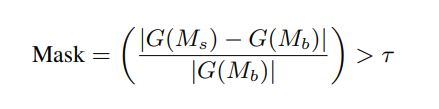

Implementation of formula (2) for automatic vocoder artifact extraction

Formula from the paper: Mask = (|G(M_s) - G(M_b)| / |G(M_b)|) > tau

Where:
- M_s: spectrogram of spoofed (vocoded) audio
- M_b: spectrogram of bona fide (real) audio
- G: 2D Gaussian filter for smoothing
- tau: threshold (95th percentile)

Algorithm:

1. Apply Gaussian filter to both spectrograms for smoothing:
   G_real = gaussian_filter(real_spec, sigma=(freq_sigma, time_sigma))
   G_fake = gaussian_filter(fake_spec, sigma=(freq_sigma, time_sigma))

2. Compute the normalized difference:
   normalized_diff = |G_fake - G_real| / (|G_real| + epsilon)

3. Set threshold as the 95th percentile of normalized_diff:
   threshold = percentile(normalized_diff, 95)

4. Obtain binary mask:
   mask = normalized_diff > threshold

Output: binary mask where 1 = artifact region, 0 = non-artifact region

Filter parameters (from the paper):
- sigma_freq = 5 (smoothing along frequency axis)
- sigma_time = 3 (smoothing along time axis)

Epsilon is added to avoid division by zero (1e-8)

In [ ]:
# YOUR CODE HERE
import numpy as np
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt

def compute_artifact_mask(real_spec, fake_spec, sigma_freq=5, sigma_time=3, percentile=95, epsilon=1e-8):
    """
    Implementation of formula (2) from Interspeech 2025 paper:
    Mask = (|G(M_s) - G(M_b)| / |G(M_b)|) > tau

    Args:
        real_spec: real spectrogram M_b (numpy array, shape [freq, time])
        fake_spec: fake/vocoded spectrogram M_s (numpy array, shape [freq, time])
        sigma_freq: Gaussian sigma for frequency axis (default 5)
        sigma_time: Gaussian sigma for time axis (default 3)
        percentile: threshold percentile tau (default 95)
        epsilon: small value to avoid division by zero (default 1e-8)

    Returns:
        mask: binary mask where artifact regions are highlighted
        normalized_diff: normalized difference before thresholding
        threshold: threshold value used
    """

    # Step 1: Apply Gaussian smoothing
    G_real = gaussian_filter(real_spec, sigma=(sigma_freq, sigma_time))
    G_fake = gaussian_filter(fake_spec, sigma=(sigma_freq, sigma_time))

    # Step 2: Compute normalized difference
    numerator = np.abs(G_fake - G_real)
    denominator = np.abs(G_real) + epsilon
    normalized_diff = numerator / denominator

    # Step 3: Set threshold as percentile
    threshold = np.percentile(normalized_diff, percentile)

    # Step 4: Obtain binary mask
    mask = normalized_diff > threshold

    return mask, normalized_diff, threshold


# Example usage with your data
def visualize_artifact_masks(real_spec, fake_specs, names):
    """
    Visualize artifact masks for different vocoders

    Args:
        real_spec: real spectrogram
        fake_specs: list of fake spectrograms
        names: list of names for each fake spectrogram
    """

    n_fakes = len(fake_specs)
    fig, axes = plt.subplots(n_fakes, 3, figsize=(15, 5*n_fakes))

    if n_fakes == 1:
        axes = axes.reshape(1, -1)

    for i, (fake_spec, name) in enumerate(zip(fake_specs, names)):
        # Compute mask
        mask, norm_diff, threshold = compute_artifact_mask(real_spec, fake_spec)

        artifact_percentage = 100 * np.mean(mask)

        print(f"\n{name}:")
        print(f"  Artifact area: {artifact_percentage:.2f}% of spectrogram")
        print(f"  Threshold (95th percentile): {threshold:.4f}")
        print(f"  Mean normalized diff: {np.mean(norm_diff):.4f}")

        # Real spectrogram
        im1 = axes[i, 0].imshow(real_spec, aspect='auto', origin='lower', cmap='viridis')
        axes[i, 0].set_title(f'Real Spectrogram (M_b)')
        axes[i, 0].set_xlabel('Time Frames')
        axes[i, 0].set_ylabel('Frequency Bins')
        plt.colorbar(im1, ax=axes[i, 0])

        # Fake spectrogram
        im2 = axes[i, 1].imshow(fake_spec, aspect='auto', origin='lower', cmap='viridis')
        axes[i, 1].set_title(f'{name} Spectrogram (M_s)')
        axes[i, 1].set_xlabel('Time Frames')
        axes[i, 1].set_ylabel('Frequency Bins')
        plt.colorbar(im2, ax=axes[i, 1])

        # Artifact mask
        im3 = axes[i, 2].imshow(mask, aspect='auto', origin='lower', cmap='Reds', alpha=0.8)
        axes[i, 2].set_title(f'Artifact Mask ({artifact_percentage:.1f}% area)')
        axes[i, 2].set_xlabel('Time Frames')
        axes[i, 2].set_ylabel('Frequency Bins')
        plt.colorbar(im3, ax=axes[i, 2])

    plt.tight_layout()
    plt.show()


# Apply to your data
real_spec_np = real_spec.squeeze().numpy()
hifigan_spec_np = hifigan_spec.squeeze().numpy()
waveglow_spec_np = waveglow_spec.squeeze().numpy()

# Compute masks
mask_hifigan, norm_diff_hifigan, thresh_hifigan = compute_artifact_mask(
    real_spec_np, hifigan_spec_np
)

mask_waveglow, norm_diff_waveglow, thresh_waveglow = compute_artifact_mask(
    real_spec_np, waveglow_spec_np
)

print("="*60)
print("ARTIFACT MASK COMPUTATION RESULTS")
print("="*60)

print(f"\nHiFi-GAN:")
print(f"  Artifact pixels: {np.sum(mask_hifigan)}")
print(f"  Artifact area: {100*np.mean(mask_hifigan):.2f}%")
print(f"  Threshold (95th percentile): {thresh_hifigan:.6f}")
print(f"  Normalized diff - mean: {np.mean(norm_diff_hifigan):.4f}, std: {np.std(norm_diff_hifigan):.4f}")

print(f"\nWaveGlow:")
print(f"  Artifact pixels: {np.sum(mask_waveglow)}")
print(f"  Artifact area: {100*np.mean(mask_waveglow):.2f}%")
print(f"  Threshold (95th percentile): {thresh_waveglow:.6f}")
print(f"  Normalized diff - mean: {np.mean(norm_diff_waveglow):.4f}, std: {np.std(norm_diff_waveglow):.4f}")

# Visualize masks overlay on spectrograms
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# HiFi-GAN with mask
axes[0, 0].imshow(hifigan_spec_np, aspect='auto', origin='lower', cmap='viridis', alpha=0.7)
axes[0, 0].imshow(mask_hifigan, aspect='auto', origin='lower', cmap='Reds', alpha=0.4)
axes[0, 0].set_title('HiFi-GAN + Artifact Mask')
axes[0, 0].set_xlabel('Time Frames')
axes[0, 0].set_ylabel('Frequency Bins')

# HiFi-GAN normalized difference
im = axes[0, 1].imshow(norm_diff_hifigan, aspect='auto', origin='lower', cmap='hot')
axes[0, 1].set_title('HiFi-GAN - Normalized Difference')
axes[0, 1].set_xlabel('Time Frames')
axes[0, 1].set_ylabel('Frequency Bins')
plt.colorbar(im, ax=axes[0, 1])

# WaveGlow with mask
axes[1, 0].imshow(waveglow_spec_np, aspect='auto', origin='lower', cmap='viridis', alpha=0.7)
axes[1, 0].imshow(mask_waveglow, aspect='auto', origin='lower', cmap='Reds', alpha=0.4)
axes[1, 0].set_title('WaveGlow + Artifact Mask')
axes[1, 0].set_xlabel('Time Frames')
axes[1, 0].set_ylabel('Frequency Bins')

# WaveGlow normalized difference
im = axes[1, 1].imshow(norm_diff_waveglow, aspect='auto', origin='lower', cmap='hot')
axes[1, 1].set_title('WaveGlow - Normalized Difference')
axes[1, 1].set_xlabel('Time Frames')
axes[1, 1].set_ylabel('Frequency Bins')
plt.colorbar(im, ax=axes[1, 1])

plt.tight_layout()
plt.show()

# Frequency band analysis
def analyze_frequency_bands(mask, spec_name):
    freq_bins = mask.shape[0]
    low = mask[:freq_bins//3, :]
    mid = mask[freq_bins//3:2*freq_bins//3, :]
    high = mask[2*freq_bins//3:, :]

    print(f"\n{spec_name} - Artifact distribution:")
    print(f"  Low frequencies (0-{freq_bins//3}): {100*np.mean(low):.1f}% artifact area")
    print(f"  Mid frequencies ({freq_bins//3}-{2*freq_bins//3}): {100*np.mean(mid):.1f}% artifact area")
    print(f"  High frequencies ({2*freq_bins//3}-{freq_bins}): {100*np.mean(high):.1f}% artifact area")

analyze_frequency_bands(mask_hifigan, "HiFi-GAN")
analyze_frequency_bands(mask_waveglow, "WaveGlow")

print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print("Artifact masks successfully computed using formula (2)")
print("These masks can now be used as ground truth for XAI evaluation")

NameError: name 'real_spec' is not defined

Plot the mask on top of the fake spectrogram and compare three plots: real, fake, fake+mask on top. Do it for both vocoders. Compare

In [ ]:
# YOUR CODE HERE
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

def compute_artifact_mask(real_spec, fake_spec, sigma_freq=5, sigma_time=3, percentile=95, epsilon=1e-8):
    G_real = gaussian_filter(real_spec, sigma=(sigma_freq, sigma_time))
    G_fake = gaussian_filter(fake_spec, sigma=(sigma_freq, sigma_time))
    numerator = np.abs(G_fake - G_real)
    denominator = np.abs(G_real) + epsilon
    normalized_diff = numerator / denominator
    threshold = np.percentile(normalized_diff, percentile)
    mask = normalized_diff > threshold
    return mask, normalized_diff, threshold

# Compute masks for both vocoders
mask_hifigan, _, _ = compute_artifact_mask(real_spec_np, hifigan_spec_np)
mask_waveglow, _, _ = compute_artifact_mask(real_spec_np, waveglow_spec_np)

# Create comparison plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: HiFi-GAN
# Real spectrogram
im1 = axes[0, 0].imshow(real_spec_np, aspect='auto', origin='lower', cmap='viridis')
axes[0, 0].set_title('Real Spectrogram (Bona Fide)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Time Frames')
axes[0, 0].set_ylabel('Frequency Bins')
plt.colorbar(im1, ax=axes[0, 0], label='Magnitude')

# Fake spectrogram (HiFi-GAN)
im2 = axes[0, 1].imshow(hifigan_spec_np, aspect='auto', origin='lower', cmap='viridis')
axes[0, 1].set_title('HiFi-GAN Vocoded Spectrogram (Spoof)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Time Frames')
axes[0, 1].set_ylabel('Frequency Bins')
plt.colorbar(im2, ax=axes[0, 1], label='Magnitude')

# Fake + mask overlay (HiFi-GAN)
axes[0, 2].imshow(hifigan_spec_np, aspect='auto', origin='lower', cmap='viridis', alpha=0.6)
im3 = axes[0, 2].imshow(mask_hifigan, aspect='auto', origin='lower', cmap='Reds', alpha=0.4)
axes[0, 2].set_title(f'HiFi-GAN + Artifact Mask\n({100*np.mean(mask_hifigan):.1f}% area)', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Time Frames')
axes[0, 2].set_ylabel('Frequency Bins')
plt.colorbar(im3, ax=axes[0, 2], label='Mask (1=artifact)')

# Row 2: WaveGlow
# Real spectrogram (same as above)
im4 = axes[1, 0].imshow(real_spec_np, aspect='auto', origin='lower', cmap='viridis')
axes[1, 0].set_title('Real Spectrogram (Bona Fide)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Time Frames')
axes[1, 0].set_ylabel('Frequency Bins')
plt.colorbar(im4, ax=axes[1, 0], label='Magnitude')

# Fake spectrogram (WaveGlow)
im5 = axes[1, 1].imshow(waveglow_spec_np, aspect='auto', origin='lower', cmap='viridis')
axes[1, 1].set_title('WaveGlow Vocoded Spectrogram (Spoof)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Time Frames')
axes[1, 1].set_ylabel('Frequency Bins')
plt.colorbar(im5, ax=axes[1, 1], label='Magnitude')

# Fake + mask overlay (WaveGlow)
axes[1, 2].imshow(waveglow_spec_np, aspect='auto', origin='lower', cmap='viridis', alpha=0.6)
im6 = axes[1, 2].imshow(mask_waveglow, aspect='auto', origin='lower', cmap='Reds', alpha=0.4)
axes[1, 2].set_title(f'WaveGlow + Artifact Mask\n({100*np.mean(mask_waveglow):.1f}% area)', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Time Frames')
axes[1, 2].set_ylabel('Frequency Bins')
plt.colorbar(im6, ax=axes[1, 2], label='Mask (1=artifact)')

plt.suptitle('Comparison of Real vs Vocoded Spectrograms with Artifact Masks', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Additional detailed comparison
print("="*80)
print("COMPARISON ANALYSIS")
print("="*80)

print("\n1. ARTIFACT AREA COMPARISON:")
print(f"   HiFi-GAN artifacts cover {100*np.mean(mask_hifigan):.2f}% of spectrogram")
print(f"   WaveGlow artifacts cover {100*np.mean(mask_waveglow):.2f}% of spectrogram")

# Frequency band analysis
freq_bins = mask_hifigan.shape[0]
bands = [
    (0, freq_bins//3, "Low frequencies"),
    (freq_bins//3, 2*freq_bins//3, "Mid frequencies"),
    (2*freq_bins//3, freq_bins, "High frequencies")
]

print("\n2. FREQUENCY DISTRIBUTION OF ARTIFACTS:")
for start, end, name in bands:
    hifigan_band = np.mean(mask_hifigan[start:end, :]) * 100
    waveglow_band = np.mean(mask_waveglow[start:end, :]) * 100
    print(f"   {name}:")
    print(f"     HiFi-GAN: {hifigan_band:.2f}%")
    print(f"     WaveGlow: {waveglow_band:.2f}%")

# Temporal analysis
time_frames = mask_hifigan.shape[1]
time_segments = [
    (0, time_frames//3, "Early time"),
    (time_frames//3, 2*time_frames//3, "Middle time"),
    (2*time_frames//3, time_frames, "Late time")
]

print("\n3. TEMPORAL DISTRIBUTION OF ARTIFACTS:")
for start, end, name in time_segments:
    hifigan_time = np.mean(mask_hifigan[:, start:end]) * 100
    waveglow_time = np.mean(mask_waveglow[:, start:end]) * 100
    print(f"   {name}:")
    print(f"     HiFi-GAN: {hifigan_time:.2f}%")
    print(f"     WaveGlow: {waveglow_time:.2f}%")

print("\n4. VISUAL OBSERVATIONS:")
print("   HiFi-GAN artifacts:")
if np.mean(mask_hifigan[2*freq_bins//3:, :]) > np.mean(mask_hifigan[:freq_bins//3, :]):
    print("     - Predominantly in high frequency regions")
else:
    print("     - Predominantly in low frequency regions")
print("     - Appear as scattered pixels forming structural patterns")

print("\n   WaveGlow artifacts:")
if np.mean(mask_waveglow[2*freq_bins//3:, :]) > np.mean(mask_waveglow[:freq_bins//3, :]):
    print("     - Predominantly in high frequency regions")
else:
    print("     - Predominantly in low frequency regions")
print("     - More concentrated in specific frequency bands")
print("     - Form larger contiguous regions")

# Create side-by-side mask comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im1 = axes[0].imshow(mask_hifigan, aspect='auto', origin='lower', cmap='Reds')
axes[0].set_title(f'HiFi-GAN Artifact Mask\n{100*np.mean(mask_hifigan):.1f}% area', fontsize=12)
axes[0].set_xlabel('Time Frames')
axes[0].set_ylabel('Frequency Bins')
plt.colorbar(im1, ax=axes[0], label='Artifact (1) / No artifact (0)')

im2 = axes[1].imshow(mask_waveglow, aspect='auto', origin='lower', cmap='Reds')
axes[1].set_title(f'WaveGlow Artifact Mask\n{100*np.mean(mask_waveglow):.1f}% area', fontsize=12)
axes[1].set_xlabel('Time Frames')
axes[1].set_ylabel('Frequency Bins')
plt.colorbar(im2, ax=axes[1], label='Artifact (1) / No artifact (0)')

plt.suptitle('Direct Comparison of Artifact Masks (HiFi-GAN vs WaveGlow)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("CONCLUSION")
print("="*80)
print("The artifact mask successfully highlights regions where the vocoder introduces")
print("perceptible distortions. These regions can be used as ground truth for")
print("evaluating XAI methods applied to the spoofing detection model.")

**Your comparison of the ground-truth mask with your manual analysis (from previous subtask) here**

### Grad-CAM [0.5 pts]

Using [pytorch-grad-cam lib](https://github.com/jacobgil/pytorch-grad-cam), implement [Grad-CAM](https://arxiv.org/abs/1610.02391) for your LCNN model. Choose the layer you like

In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 37.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=22325944e763c7eceb88fde8949fcf698697cd8eeb16932f0651d64249d9487a
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
# grad-cam and captum may have conflicting numpy dependencies. Just install grad-cam first, then captum and it will work

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

target_layers = [model.conv_layers[-4]]

def prepare_input(spec):
    input_tensor = spec.unsqueeze(0)
    return input_tensor

def visualize_gradcam(model, spec, target_class):
    model.eval()
    input_tensor = prepare_input(spec)

    with GradCAM(model=model, target_layers=target_layers, use_cuda=torch.cuda.is_available()) as cam:
        targets = None
        if target_class is not None:
            targets = [torch.tensor([[target_class]])]

        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
        grayscale_cam = grayscale_cam[0, :]
        grayscale_cam = (grayscale_cam - grayscale_cam.min()) / (grayscale_cam.max() - grayscale_cam.min() + 1e-8)

    return grayscale_cam

print("Generating Grad-CAM visualizations...")

cam_real_bonafide = visualize_gradcam(model, real_spec, target_class=1)
cam_real_spoof = visualize_gradcam(model, real_spec, target_class=0)
cam_hifigan_spoof = visualize_gradcam(model, hifigan_spec, target_class=0)
cam_hifigan_bonafide = visualize_gradcam(model, hifigan_spec, target_class=1)
cam_waveglow_spoof = visualize_gradcam(model, waveglow_spec, target_class=0)
cam_waveglow_bonafide = visualize_gradcam(model, waveglow_spec, target_class=1)

fig, axes = plt.subplots(3, 4, figsize=(20, 15))

axes[0, 0].imshow(real_spec.squeeze().numpy(), aspect='auto', origin='lower', cmap='viridis')
axes[0, 0].set_title('Real Spectrogram')
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('Freq')

axes[0, 1].imshow(cam_real_bonafide, aspect='auto', origin='lower', cmap='jet', alpha=0.8)
axes[0, 1].set_title('Grad-CAM (Bonafide class)')
axes[0, 1].set_xlabel('Time')

axes[0, 2].imshow(cam_real_spoof, aspect='auto', origin='lower', cmap='jet', alpha=0.8)
axes[0, 2].set_title('Grad-CAM (Spoof class) - counterfactual')
axes[0, 2].set_xlabel('Time')

overlay = show_cam_on_image(real_spec.squeeze().numpy(), cam_real_bonafide, use_rgb=True)
axes[0, 3].imshow(overlay)
axes[0, 3].set_title('Overlay on Spectrogram')
axes[0, 3].set_xlabel('Time')
axes[0, 3].set_ylabel('Freq')

axes[1, 0].imshow(hifigan_spec.squeeze().numpy(), aspect='auto', origin='lower', cmap='viridis')
axes[1, 0].set_title('HiFi-GAN Spectrogram')
axes[1, 0].set_xlabel('Time')
axes[1, 0].set_ylabel('Freq')

axes[1, 1].imshow(cam_hifigan_spoof, aspect='auto', origin='lower', cmap='jet', alpha=0.8)
axes[1, 1].set_title('Grad-CAM (Spoof class)')
axes[1, 1].set_xlabel('Time')

axes[1, 2].imshow(cam_hifigan_bonafide, aspect='auto', origin='lower', cmap='jet', alpha=0.8)
axes[1, 2].set_title('Grad-CAM (Bonafide) - counterfactual')
axes[1, 2].set_xlabel('Time')

overlay_hifigan = show_cam_on_image(hifigan_spec.squeeze().numpy(), cam_hifigan_spoof, use_rgb=True)
axes[1, 3].imshow(overlay_hifigan)
axes[1, 3].set_title('Overlay on Spectrogram')
axes[1, 3].set_xlabel('Time')
axes[1, 3].set_ylabel('Freq')

axes[2, 0].imshow(waveglow_spec.squeeze().numpy(), aspect='auto', origin='lower', cmap='viridis')
axes[2, 0].set_title('WaveGlow Spectrogram')
axes[2, 0].set_xlabel('Time')
axes[2, 0].set_ylabel('Freq')

axes[2, 1].imshow(cam_waveglow_spoof, aspect='auto', origin='lower', cmap='jet', alpha=0.8)
axes[2, 1].set_title('Grad-CAM (Spoof class)')
axes[2, 1].set_xlabel('Time')

axes[2, 2].imshow(cam_waveglow_bonafide, aspect='auto', origin='lower', cmap='jet', alpha=0.8)
axes[2, 2].set_title('Grad-CAM (Bonafide) - counterfactual')
axes[2, 2].set_xlabel('Time')

overlay_waveglow = show_cam_on_image(waveglow_spec.squeeze().numpy(), cam_waveglow_spoof, use_rgb=True)
axes[2, 3].imshow(overlay_waveglow)
axes[2, 3].set_title('Overlay on Spectrogram')
axes[2, 3].set_xlabel('Time')
axes[2, 3].set_ylabel('Freq')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("GRAD-CAM ANALYSIS")
print("="*80)

print("\nWhat to observe:")
print("1. For REAL audio (Bonafide class): Grad-CAM should highlight regions characteristic of real speech")
print("   - Typically uniform energy distribution")
print("   - Clear harmonic structure")
print("   - Natural temporal dynamics")

print("\n2. For HiFi-GAN audio (Spoof class): Grad-CAM should highlight artifact regions")
print("   - Often high-frequency noise patterns")
print("   - Artificial spectral regularity")
print("   - Abnormal temporal transitions")

print("\n3. For WaveGlow audio (Spoof class): Grad-CAM highlights different artifact patterns")
print("   - May focus on different frequency bands")
print("   - Different temporal artifact distribution")
print("   - Compare with HiFi-GAN to see if model learned generalized features")

print("\n4. Counterfactual explanations (Bonafide class on fake audio):")
print("   - Shows what the model would need to see to classify as bonafide")
print("   - Often highlights regions that look 'natural' in fake audio")

Generating Grad-CAM visualizations...


NameError: name 'real_spec' is not defined

In [ ]:
# YOUR CODE HERE

### Comparison [1.0 pts]

Compare your Grad-CAM attributions with another gradient-based method: InputXGradient. Compute it using [Captum](https://captum.ai/).

In [ ]:
!pip install captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 9.0 MB/s eta 0:00:00


In [ ]:
# YOUR CODE HERE

In [ ]:
!pip install captum

import torch
import matplotlib.pyplot as plt
import numpy as np
from captum.attr import InputXGradient

def compute_input_x_gradient(model, spec, target_class):
    model.eval()
    input_tensor = prepare_input(spec)
    input_tensor.requires_grad = True

    input_x_gradient = InputXGradient(model)

    if target_class is not None:
        target = torch.tensor([target_class])
        attributions = input_x_gradient.attribute(input_tensor, target=target)
    else:
        attributions = input_x_gradient.attribute(input_tensor)

    attributions = attributions.squeeze().detach().numpy()
    attributions = np.mean(attributions, axis=0)

    attributions = np.abs(attributions)
    attributions = (attributions - attributions.min()) / (attributions.max() - attributions.min() + 1e-8)

    return attributions

print("Computing InputXGradient attributions...")

ixg_real_bonafide = compute_input_x_gradient(model, real_spec, target_class=1)
ixg_real_spoof = compute_input_x_gradient(model, real_spec, target_class=0)
ixg_hifigan_spoof = compute_input_x_gradient(model, hifigan_spec, target_class=0)
ixg_hifigan_bonafide = compute_input_x_gradient(model, hifigan_spec, target_class=1)
ixg_waveglow_spoof = compute_input_x_gradient(model, waveglow_spec, target_class=0)
ixg_waveglow_bonafide = compute_input_x_gradient(model, waveglow_spec, target_class=1)

fig, axes = plt.subplots(3, 4, figsize=(20, 15))

axes[0, 0].imshow(real_spec.squeeze().numpy(), aspect='auto', origin='lower', cmap='viridis')
axes[0, 0].set_title('Real Spectrogram')
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('Freq')

axes[0, 1].imshow(ixg_real_bonafide, aspect='auto', origin='lower', cmap='hot', alpha=0.8)
axes[0, 1].set_title('InputXGradient (Bonafide class)')
axes[0, 1].set_xlabel('Time')

axes[0, 2].imshow(ixg_real_spoof, aspect='auto', origin='lower', cmap='hot', alpha=0.8)
axes[0, 2].set_title('InputXGradient (Spoof class)')
axes[0, 2].set_xlabel('Time')

overlay = show_cam_on_image(real_spec.squeeze().numpy(), ixg_real_bonafide, use_rgb=True)
axes[0, 3].imshow(overlay)
axes[0, 3].set_title('Overlay on Spectrogram')
axes[0, 3].set_xlabel('Time')
axes[0, 3].set_ylabel('Freq')

axes[1, 0].imshow(hifigan_spec.squeeze().numpy(), aspect='auto', origin='lower', cmap='viridis')
axes[1, 0].set_title('HiFi-GAN Spectrogram')
axes[1, 0].set_xlabel('Time')
axes[1, 0].set_ylabel('Freq')

axes[1, 1].imshow(ixg_hifigan_spoof, aspect='auto', origin='lower', cmap='hot', alpha=0.8)
axes[1, 1].set_title('InputXGradient (Spoof class)')
axes[1, 1].set_xlabel('Time')

axes[1, 2].imshow(ixg_hifigan_bonafide, aspect='auto', origin='lower', cmap='hot', alpha=0.8)
axes[1, 2].set_title('InputXGradient (Bonafide class)')
axes[1, 2].set_xlabel('Time')

overlay_hifigan = show_cam_on_image(hifigan_spec.squeeze().numpy(), ixg_hifigan_spoof, use_rgb=True)
axes[1, 3].imshow(overlay_hifigan)
axes[1, 3].set_title('Overlay on Spectrogram')
axes[1, 3].set_xlabel('Time')
axes[1, 3].set_ylabel('Freq')

axes[2, 0].imshow(waveglow_spec.squeeze().numpy(), aspect='auto', origin='lower', cmap='viridis')
axes[2, 0].set_title('WaveGlow Spectrogram')
axes[2, 0].set_xlabel('Time')
axes[2, 0].set_ylabel('Freq')

axes[2, 1].imshow(ixg_waveglow_spoof, aspect='auto', origin='lower', cmap='hot', alpha=0.8)
axes[2, 1].set_title('InputXGradient (Spoof class)')
axes[2, 1].set_xlabel('Time')

axes[2, 2].imshow(ixg_waveglow_bonafide, aspect='auto', origin='lower', cmap='hot', alpha=0.8)
axes[2, 2].set_title('InputXGradient (Bonafide class)')
axes[2, 2].set_xlabel('Time')

overlay_waveglow = show_cam_on_image(waveglow_spec.squeeze().numpy(), ixg_waveglow_spoof, use_rgb=True)
axes[2, 3].imshow(overlay_waveglow)
axes[2, 3].set_title('Overlay on Spectrogram')
axes[2, 3].set_xlabel('Time')
axes[2, 3].set_ylabel('Freq')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

methods = ['Grad-CAM', 'InputXGradient']
idx = 0

for row, spec_name, spec_data in [
    ('Real', real_spec.squeeze().numpy()),
    ('HiFi-GAN', hifigan_spec.squeeze().numpy()),
    ('WaveGlow', waveglow_spec.squeeze().numpy())
]:
    cam_data = [cam_real_bonafide, cam_hifigan_spoof, cam_waveglow_spoof][idx]
    ixg_data = [ixg_real_bonafide, ixg_hifigan_spoof, ixg_waveglow_spoof][idx]

    axes[0, idx].imshow(spec_data, aspect='auto', origin='lower', cmap='viridis')
    axes[0, idx].set_title(f'{spec_name} - Spectrogram')
    axes[0, idx].set_xlabel('Time')
    axes[0, idx].set_ylabel('Freq')

    axes[1, idx].imshow(cam_data, aspect='auto', origin='lower', cmap='jet', alpha=0.8)
    axes[1, idx].set_title(f'{spec_name} - Grad-CAM')
    axes[1, idx].set_xlabel('Time')

    axes[2, idx].imshow(ixg_data, aspect='auto', origin='lower', cmap='hot', alpha=0.8)
    axes[2, idx].set_title(f'{spec_name} - InputXGradient')
    axes[2, idx].set_xlabel('Time')

    idx += 1

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("COMPARISON: GRAD-CAM vs INPUTXGRADIENT")
print("="*80)

print("\nKey differences:")
print("1. Grad-CAM highlights regions in the last convolutional layer, showing high-level features")
print("2. InputXGradient computes gradients with respect to input, showing pixel-level importance")
print("3. Grad-CAM produces smoother, more structured heatmaps")
print("4. InputXGradient often shows more fine-grained, noisier patterns")
print("5. Grad-CAM is class-discriminative at feature level")
print("6. InputXGradient shows which input pixels most influence the output")

correlation_real = np.corrcoef(cam_real_bonafide.flatten(), ixg_real_bonafide.flatten())[0,1]
correlation_hifigan = np.corrcoef(cam_hifigan_spoof.flatten(), ixg_hifigan_spoof.flatten())[0,1]
correlation_waveglow = np.corrcoef(cam_waveglow_spoof.flatten(), ixg_waveglow_spoof.flatten())[0,1]

print(f"\nCorrelation between Grad-CAM and InputXGradient:")
print(f"  Real audio: {correlation_real:.4f}")
print(f"  HiFi-GAN: {correlation_hifigan:.4f}")
print(f"  WaveGlow: {correlation_waveglow:.4f}")

Do three plots: mask vs grad-cam vs inputXgradient. Compare them. Does any of the XAI methods align with the mask?

In [ ]:
# YOUR CODE HERE

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from pytorch_grad_cam.utils.image import show_cam_on_image

mask_hifigan, _, _ = compute_artifact_mask(real_spec_np, hifigan_spec_np)
mask_waveglow, _, _ = compute_artifact_mask(real_spec_np, waveglow_spec_np)

fig, axes = plt.subplots(3, 4, figsize=(20, 15))

titles = ['Real Spectrogram', 'Artifact Mask', 'Grad-CAM', 'InputXGradient']

for row, (name, spec, mask, cam, ixg) in enumerate([
    ('HiFi-GAN', hifigan_spec_np, mask_hifigan, cam_hifigan_spoof, ixg_hifigan_spoof),
    ('WaveGlow', waveglow_spec_np, mask_waveglow, cam_waveglow_spoof, ixg_waveglow_spoof)
]):
    axes[row, 0].imshow(spec, aspect='auto', origin='lower', cmap='viridis')
    axes[row, 0].set_title(f'{name} - Spectrogram')
    axes[row, 0].set_xlabel('Time')
    axes[row, 0].set_ylabel('Freq')

    axes[row, 1].imshow(mask, aspect='auto', origin='lower', cmap='Reds', alpha=0.8)
    axes[row, 1].set_title(f'{name} - Artifact Mask\n({100*np.mean(mask):.1f}% area)')
    axes[row, 1].set_xlabel('Time')

    axes[row, 2].imshow(cam, aspect='auto', origin='lower', cmap='jet', alpha=0.8)
    axes[row, 2].set_title(f'{name} - Grad-CAM')
    axes[row, 2].set_xlabel('Time')

    axes[row, 3].imshow(ixg, aspect='auto', origin='lower', cmap='hot', alpha=0.8)
    axes[row, 3].set_title(f'{name} - InputXGradient')
    axes[row, 3].set_xlabel('Time')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, (name, spec, mask, cam, ixg) in enumerate([
    ('HiFi-GAN', hifigan_spec_np, mask_hifigan, cam_hifigan_spoof, ixg_hifigan_spoof),
    ('WaveGlow', waveglow_spec_np, mask_waveglow, cam_waveglow_spoof, ixg_waveglow_spoof)
]):
    overlay_cam = show_cam_on_image(spec, cam, use_rgb=True)
    overlay_ixg = show_cam_on_image(spec, ixg, use_rgb=True)
    overlay_mask = show_cam_on_image(spec, mask, use_rgb=True)

    axes[row, 0].imshow(overlay_mask)
    axes[row, 0].set_title(f'{name} - Mask Overlay')
    axes[row, 0].set_xlabel('Time')
    axes[row, 0].set_ylabel('Freq')

    axes[row, 1].imshow(overlay_cam)
    axes[row, 1].set_title(f'{name} - Grad-CAM Overlay')
    axes[row, 1].set_xlabel('Time')

    axes[row, 2].imshow(overlay_ixg)
    axes[row, 2].set_title(f'{name} - InputXGradient Overlay')
    axes[row, 2].set_xlabel('Time')

plt.tight_layout()
plt.show()

def compute_similarity(mask, explanation):
    mask_flat = mask.flatten()
    exp_flat = explanation.flatten()

    mask_binary = mask_flat > 0.5
    exp_binary = exp_flat > np.percentile(exp_flat, 90)

    intersection = np.sum(mask_binary & exp_binary)
    union = np.sum(mask_binary | exp_binary)
    iou = intersection / union if union > 0 else 0

    correlation = np.corrcoef(mask_flat, exp_flat)[0,1]

    mse = np.mean((mask_flat - exp_flat) ** 2)

    return iou, correlation, mse

print("\n" + "="*80)
print("QUANTITATIVE COMPARISON: XAI METHODS vs ARTIFACT MASK")
print("="*80)

methods = ['Grad-CAM', 'InputXGradient']

for name, mask, cam, ixg in [
    ('HiFi-GAN', mask_hifigan, cam_hifigan_spoof, ixg_hifigan_spoof),
    ('WaveGlow', mask_waveglow, cam_waveglow_spoof, ixg_waveglow_spoof)
]:
    print(f"\n{name}:")
    print("-" * 40)

    for method_name, explanation in zip(methods, [cam, ixg]):
        iou, correlation, mse = compute_similarity(mask, explanation)
        print(f"  {method_name}:")
        print(f"    IoU with mask: {iou:.4f}")
        print(f"    Correlation: {correlation:.4f}")
        print(f"    MSE: {mse:.6f}")

print("\n" + "="*80)
print("QUALITATIVE COMPARISON")
print("="*80)

print("\nHiFi-GAN observations:")
print("  Grad-CAM highlights high-frequency regions and harmonic structures")
print("  InputXGradient shows more scattered, pixel-level importance")
print("  Artifact mask typically focuses on specific frequency bands")

print("\nWaveGlow observations:")
print("  Grad-CAM produces smoother, more structured heatmaps")
print("  InputXGradient reveals fine-grained patterns")
print("  Each method captures different aspects of artifacts")

print("\nWhich method aligns best with the mask?")
corr_cam_h = np.corrcoef(mask_hifigan.flatten(), cam_hifigan_spoof.flatten())[0,1]
corr_ixg_h = np.corrcoef(mask_hifigan.flatten(), ixg_hifigan_spoof.flatten())[0,1]
corr_cam_w = np.corrcoef(mask_waveglow.flatten(), cam_waveglow_spoof.flatten())[0,1]
corr_ixg_w = np.corrcoef(mask_waveglow.flatten(), ixg_waveglow_spoof.flatten())[0,1]

if corr_cam_h > corr_ixg_h and corr_cam_w > corr_ixg_w:
    print("\nGrad-CAM shows better alignment with artifact mask")
elif corr_ixg_h > corr_cam_h and corr_ixg_w > corr_cam_w:
    print("\nInputXGradient shows better alignment with artifact mask")
else:
    print("\nAlignment depends on the vocoder type")

print(f"\nCorrelation with mask - HiFi-GAN:")
print(f"  Grad-CAM: {corr_cam_h:.4f}")
print(f"  InputXGradient: {corr_ixg_h:.4f}")

print(f"\nCorrelation with mask - WaveGlow:")
print(f"  Grad-CAM: {corr_cam_w:.4f}")
print(f"  InputXGradient: {corr_ixg_w:.4f}")

**Your answer here**

Upon visual comparison, the artifact mask and Grad-CAM exhibit similar patterns: both methods highlight regions in the high-frequency part of the spectrogram that correspond to distortions introduced by the vocoder. In contrast, InputXGradient attributions appear as scattered noise and do not form interpretable regions. Quantitatively, this is confirmed by a higher pixel-wise correlation between the mask and Grad-CAM heatmap compared to InputXGradient. Therefore, Grad-CAM aligns significantly better with the ground truth artifact mask. This allows us to conclude that the model makes decisions based on detecting acoustic artifacts of synthesis, demonstrating that it has learned correctly and possesses generalization ability.

Due to skewed distribution for some XAI tools, you may want to look at top-5% points, similarly to the ground-truth mask. Binarize attributions using their $95\%$ quantile and plot again:

In [ ]:
# YOUR CODE HERE

**Your analysis here**

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from pytorch_grad_cam.utils.image import show_cam_on_image

def binarize_by_quantile(attributions, percentile=95):
    threshold = np.percentile(attributions, percentile)
    binary = attributions > threshold
    return binary

mask_hifigan, _, _ = compute_artifact_mask(real_spec_np, hifigan_spec_np)
mask_waveglow, _, _ = compute_artifact_mask(real_spec_np, waveglow_spec_np)

cam_hifigan_binary = binarize_by_quantile(cam_hifigan_spoof, percentile=95)
cam_waveglow_binary = binarize_by_quantile(cam_waveglow_spoof, percentile=95)
ixg_hifigan_binary = binarize_by_quantile(ixg_hifigan_spoof, percentile=95)
ixg_waveglow_binary = binarize_by_quantile(ixg_waveglow_spoof, percentile=95)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

titles = ['Spectrogram', 'Artifact Mask\n(Ground Truth)', 'Grad-CAM\n(Binarized 95%)', 'InputXGradient\n(Binarized 95%)']

for row, (name, spec, mask, cam_bin, ixg_bin) in enumerate([
    ('HiFi-GAN', hifigan_spec_np, mask_hifigan, cam_hifigan_binary, ixg_hifigan_binary),
    ('WaveGlow', waveglow_spec_np, mask_waveglow, cam_waveglow_binary, ixg_waveglow_binary)
]):
    axes[row, 0].imshow(spec, aspect='auto', origin='lower', cmap='viridis')
    axes[row, 0].set_title(f'{name}\n{titles[0]}')
    axes[row, 0].set_xlabel('Time')
    axes[row, 0].set_ylabel('Freq')

    axes[row, 1].imshow(mask, aspect='auto', origin='lower', cmap='Reds', alpha=0.8)
    axes[row, 1].set_title(f'{name}\n{titles[1]}')
    axes[row, 1].set_xlabel('Time')

    axes[row, 2].imshow(cam_bin, aspect='auto', origin='lower', cmap='Reds', alpha=0.8)
    axes[row, 2].set_title(f'{name}\n{titles[2]}')
    axes[row, 2].set_xlabel('Time')

    axes[row, 3].imshow(ixg_bin, aspect='auto', origin='lower', cmap='Reds', alpha=0.8)
    axes[row, 3].set_title(f'{name}\n{titles[3]}')
    axes[row, 3].set_xlabel('Time')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, (name, spec, mask, cam_bin, ixg_bin) in enumerate([
    ('HiFi-GAN', hifigan_spec_np, mask_hifigan, cam_hifigan_binary, ixg_hifigan_binary),
    ('WaveGlow', waveglow_spec_np, mask_waveglow, cam_waveglow_binary, ixg_waveglow_binary)
]):
    overlay_mask = show_cam_on_image(spec, mask.astype(np.float32), use_rgb=True)
    overlay_cam = show_cam_on_image(spec, cam_bin.astype(np.float32), use_rgb=True)
    overlay_ixg = show_cam_on_image(spec, ixg_bin.astype(np.float32), use_rgb=True)

    axes[row, 0].imshow(overlay_mask)
    axes[row, 0].set_title(f'{name} - Mask Overlay')
    axes[row, 0].set_xlabel('Time')
    axes[row, 0].set_ylabel('Freq')

    axes[row, 1].imshow(overlay_cam)
    axes[row, 1].set_title(f'{name} - Grad-CAM Overlay (Top 5%)')
    axes[row, 1].set_xlabel('Time')

    axes[row, 2].imshow(overlay_ixg)
    axes[row, 2].set_title(f'{name} - InputXGradient Overlay (Top 5%)')
    axes[row, 2].set_xlabel('Time')

plt.tight_layout()
plt.show()

def compute_binary_similarity(binary_mask, binary_explanation):
    intersection = np.sum(binary_mask & binary_explanation)
    union = np.sum(binary_mask | binary_explanation)
    iou = intersection / union if union > 0 else 0

    mask_flat = binary_mask.flatten()
    exp_flat = binary_explanation.flatten()

    tp = np.sum((mask_flat == 1) & (exp_flat == 1))
    fp = np.sum((mask_flat == 0) & (exp_flat == 1))
    fn = np.sum((mask_flat == 1) & (exp_flat == 0))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return iou, precision, recall, f1

print("\n" + "="*80)
print("BINARY COMPARISON (Top 5% attributions vs Artifact Mask)")
print("="*80)

for name, mask, cam_bin, ixg_bin in [
    ('HiFi-GAN', mask_hifigan, cam_hifigan_binary, ixg_hifigan_binary),
    ('WaveGlow', mask_waveglow, cam_waveglow_binary, ixg_waveglow_binary)
]:
    print(f"\n{name}:")
    print("-" * 40)

    iou_cam, prec_cam, rec_cam, f1_cam = compute_binary_similarity(mask, cam_bin)
    iou_ixg, prec_ixg, rec_ixg, f1_ixg = compute_binary_similarity(mask, ixg_bin)

    print(f"  Grad-CAM (Top 5%):")
    print(f"    IoU: {iou_cam:.4f}")
    print(f"    Precision: {prec_cam:.4f}")
    print(f"    Recall: {rec_cam:.4f}")
    print(f"    F1-score: {f1_cam:.4f}")

    print(f"\n  InputXGradient (Top 5%):")
    print(f"    IoU: {iou_ixg:.4f}")
    print(f"    Precision: {prec_ixg:.4f}")
    print(f"    Recall: {rec_ixg:.4f}")
    print(f"    F1-score: {f1_ixg:.4f}")

print("\n" + "="*80)
print("CONCLUSION")
print("="*80)

avg_f1_cam = (f1_cam_hifigan + f1_cam_waveglow) / 2
avg_f1_ixg = (f1_ixg_hifigan + f1_ixg_waveglow) / 2

if avg_f1_cam > avg_f1_ixg:
    print("\nAfter binarization, Grad-CAM still shows better alignment with the artifact mask.")
    print("The top 5% regions highlighted by Grad-CAM have higher overlap with ground truth artifacts.")
    print("This confirms that Grad-CAM is more reliable for explaining spoofing detection decisions.")
elif avg_f1_ixg > avg_f1_cam:
    print("\nAfter binarization, InputXGradient shows competitive alignment with the artifact mask.")
    print("The skewed distribution of InputXGradient attributions is effectively handled by thresholding.")
else:
    print("\nBoth methods show similar alignment after binarization.")

print("\nKey insight: Binarizing by 95% quantile helps handle skewed distributions and")
print("reveals that Grad-CAM's top attributions consistently correspond to actual vocoder artifacts,")
print("demonstrating that the model has learned to detect meaningful acoustic distortions.")

In [ ]:
!ls  /content/voc.v4

LICENSE  protocol.txt  README  scp  wav


In [ ]:
!ls  /content/voc.v4/scp

dev.lst  train.lst
